# Proposed Model: Hybrid CNN-Transformer

This notebook contains the code for training our **proposed hybrid CNN-Transformer** model. This is the main contribution of the project.

The idea is to combine a strong per-frame CNN backbone (EfficientNet-B3) with a Transformer encoder that reasons over the sequence of frame-level features. The CNN catches spatial artifacts (boundary blending, lighting inconsistencies) and the Transformer catches temporal artifacts (unnatural motion, inconsistent blinking) by attending across the 24 frames.

**Approach:**
1. Run EfficientNet-B3 on every frame independently to get a 1536-dim feature per frame. We use `number_of_classes=0` in `timm.create_model` so it returns the pre-classifier pooled feature instead of class scores.
2. Prepend a learnable `[CLS]` token, add learned positional embeddings, and pass the sequence through a 4-layer Transformer encoder (8 heads, FFN dim 2048, dropout 0.1).
3. Take the `[CLS]` token output and pass it through a small MLP head (Linear -> ReLU -> Dropout -> Linear) for the binary logit.

**Why this should beat the frame-level baselines:** The frame averagers (Xception, EfficientNet, ViT) throw away temporal information. CNN+LSTM uses temporal info but processes it sequentially, which is weaker than attention for short clips. The hybrid approach keeps the strong spatial features from a pretrained CNN and adds global temporal attention on top. We expect the bigger win to show up on the held-out FaceShifter manipulation (cross-manipulation generalization, notebook 08). Because the temporal artifacts tend to be more manipulation-agnostic than spatial ones.

**Training setup:** Same as the baselines. BCEWithLogitsLoss, AdamW (lr=1e-4, wd=1e-4), CosineAnnealingLR over 25 epochs, mixed precision, balanced sampler, ImageNet normalization, hflip + brightness jitter.

### To view TensorBoard
In PowerShell, use the following command:
```powershell
tensorboard --logdir ./results
```
Open http://localhost:6006 in your browser.

## 1. Setup

In [1]:
# Keep track of time
import time

start_time = time.perf_counter()

In [2]:
# Import nercessary libraries and the shared utilities
import json
from pathlib import Path
import random

import numpy as np
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import timm

# Import shared utilities
from utils import (
    PREPROCESSED_TENSORS_DIR_PATH,
    RESULTS_DIR_PATH,
    DeepfakeClipDataset,
    make_balanced_sampler,
    run_training,
    evaluate,
    load_checkpoint,
    plot_training_curves,
)

In [3]:
# Set the seed value
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# Enable cuDNN auto-tuner to select the fastest convolution algorithms
torch.backends.cudnn.benchmark = True

In [4]:
# Set the device
if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"GPU Name is:{torch.cuda.get_device_name(0)}")
else:
    DEVICE = "cpu"

GPU Name is:NVIDIA GeForce RTX 5080


In [5]:
# Set the hyper-parameter
model_name = "hybrid_cnn_transformer"

# number_of_epochs = 2 # For dry-run
number_of_epochs = 25
batch_size = 4
learning_rate = 1e-4
weight_decay = 1e-4
early_stopping_patience = 5

# Transformer-specific settings
transformer_number_of_layers = 4
transformer_number_of_heads = 8
transformer_feedforward_dimensions = 2048
transformer_dropout = 0.1

## 2. Build datasets and dataloaders

We use the balanced sampler on the train split to oversample reals (since fakes outnumber them 4:1).

In [6]:
# Build the dataset
splits_json_path = PREPROCESSED_TENSORS_DIR_PATH / "splits.json"
assert splits_json_path.exists(), f"Missing {splits_json_path}."

train_dataset = DeepfakeClipDataset(splits_json_path, "train", PREPROCESSED_TENSORS_DIR_PATH, training_augment=True)
validation_dataset = DeepfakeClipDataset(splits_json_path, "validation", PREPROCESSED_TENSORS_DIR_PATH, training_augment=False)
test_dataset = DeepfakeClipDataset(splits_json_path, "test", PREPROCESSED_TENSORS_DIR_PATH, training_augment=False)

print(f"Train: {len(train_dataset)} clips")
print(f"validation: {len(validation_dataset)} clips")
print(f"Test:  {len(test_dataset)} clips")

Train: 2799 clips
validation: 349 clips
Test:  351 clips


In [7]:
# Make the training dataset balanced
train_sampler = make_balanced_sampler(train_dataset)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=train_sampler,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

## 3. Define the model

The model has three parts.

1. **EfficientNet-B3 backbone** (from `timm`, pretrained on ImageNet). We set `number_of_classes=0` so it returns the global-pooled feature vector (1536 dim) instead of class logits. We run this on each frame independently.
2. **Transformer encoder** over the 24 frame features + a learnable `[CLS]` token, with learned positional embeddings for the 25 positions. We use `batch_first=True` so tensor shapes stay as `[B, T, D]`.
3. **Classification head**: Linear -> ReLU -> Dropout -> Linear -> 1 logit, applied to the `[CLS]` output.

The whole model is trained end-to-end (no backbone freezing), same as the EfficientNet baseline.

In [8]:
class HybridCNNTransformer(nn.Module):
    """EfficientNet-B3 per-frame backbone, then a Transformer encoder over the frame sequence with a CLS token."""
    
    def __init__(
        self,
        pretrained=True,
        number_of_frames=24,
        number_of_transformer_layers=4,
        number_of_heads=8,
        transformer_feedforward_dimensions=2048,
        dropout=0.1,
    ):
        super().__init__()
        
        # ------- CNN backbone -------
        # number_of_classes=0 makes timm return the pre-classifier pooled feature (1536-dim for EfficientNet-B3)
        self.backbone = timm.create_model("tf_efficientnet_b3", pretrained=pretrained, num_classes=0)
        feature_dimensions = self.backbone.num_features  # 1536 for EfficientNet-B3
        
        # ---------- CLS token + positional embeddings -------
        # CLS is a learnable vector we prepend to the frame sequence. Its final state is what we classify on
        self.cls_token = nn.Parameter(torch.zeros(1, 1, feature_dimensions))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        
        # Learned positional embeddings for 1 CLS + T frames.
        self.positional_embeddings = nn.Parameter(torch.zeros(1, number_of_frames + 1, feature_dimensions))
        nn.init.trunc_normal_(self.positional_embeddings, std=0.02)
        
        # ---------------- Transformer encoder -------
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=feature_dimensions,
            nhead=number_of_heads,
            dim_feedforward=transformer_feedforward_dimensions,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=number_of_transformer_layers)
        self.transformer_norm = nn.LayerNorm(feature_dimensions)
        
        # ------- Classification head -------
        # Tiny MLP on top of the CLS token. We keep it small to avoid overfitting on 2.8k train clips.
        self.classifier = nn.Sequential(
            nn.Linear(feature_dimensions, feature_dimensions // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(feature_dimensions // 2, 1),
        )
    
    def forward(self, clip):
        # clip: [B, T, 3, H, W]
        batch_size, number_of_frames, channels, height, width = clip.shape
        
        # --------- Per-frame features -------
        # Flatten time into batch and run the CNN. Output: [B*T, feature_dimensions]
        flat_frames = clip.view(batch_size * number_of_frames, channels, height, width)
        frame_features = self.backbone(flat_frames)
        
        # Reshape back to a sequence: [B, T, feature_dimensions]
        frame_features = frame_features.view(batch_size, number_of_frames, -1)
        
        # ----- Prepend CLS and add positions -------
        # Expand the single CLS token across the batch: [B, 1, feature_dimensions]
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        sequence = torch.cat([cls_tokens, frame_features], dim=1) # [B, T+1, feature_dimensions]
        sequence = sequence + self.positional_embeddings
        
        # ---------- Transformer -------
        sequence = self.transformer_encoder(sequence) # [B, T+1, feature_dimensions]
        sequence = self.transformer_norm(sequence)
        
        # Take the CLS token output and classify
        cls_output = sequence[:, 0]  # [B, feature_dimensions]
        clip_logits = self.classifier(cls_output) # [B, 1]
        return clip_logits


model = HybridCNNTransformer(
    pretrained=True,
    number_of_frames=24,
    number_of_transformer_layers=transformer_number_of_layers,
    number_of_heads=transformer_number_of_heads,
    transformer_feedforward_dimensions=transformer_feedforward_dimensions,
    dropout=transformer_dropout,
).to(DEVICE)


C:\Users\LabPC\AppData\Local\Temp\ipykernel_20676\1453963658.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=number_of_transformer_layers)


In [9]:
number_of_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
number_of_backbone_parameters = sum(p.numel() for p in model.backbone.parameters() if p.requires_grad)
number_of_transformer_parameters = sum(p.numel() for p in model.transformer_encoder.parameters() if p.requires_grad)
print(f"Trainable parameters: {number_of_parameters:,}  ({number_of_parameters/1e6:.1f}M)")
print(f"  Backbone (EfficientNet-B3): {number_of_backbone_parameters/1e6:.1f}M")
print(f"  Transformer encoder ({transformer_number_of_layers} layers): {number_of_transformer_parameters/1e6:.1f}M")

Trainable parameters: 74,898,473  (74.9M)
  Backbone (EfficientNet-B3): 10.7M
  Transformer encoder (4 layers): 63.0M


## 4. Optimizer, scheduler, loss

In [10]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# We use Cosine annealing as it gradually decays the LR over the training run
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=number_of_epochs)

loss_function = nn.BCEWithLogitsLoss()

print(f"Optimizer: AdamW, lr={learning_rate}, weight_decay={weight_decay}")
print(f"Scheduler: CosineAnnealingLR over {number_of_epochs} epochs")
print(f"Loss: BCEWithLogitsLoss")

Optimizer: AdamW, lr=0.0001, weight_decay=0.0001
Scheduler: CosineAnnealingLR over 25 epochs
Loss: BCEWithLogitsLoss


## 5. Train

The `run_training` helper from `utils.py` handles the full loop. That is, training epochs, validation, TensorBoard logging, early stopping, and saving the best checkpoint.

In [11]:
best_checkpoint_path = run_training(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    loss_function=loss_function,
    device=DEVICE,
    model_name=model_name,
    number_of_epochs=number_of_epochs,
    early_stopping_patience=early_stopping_patience,
    use_mixed_precision=True,
)
print(f"\nBest checkpoint saved to: {best_checkpoint_path}")


Training: hybrid_cnn_transformer
TensorBoard logs: results\hybrid_cnn_transformer\tensorboard
  Run `tensorboard --logdir C:\x-ion\TEST\results` to view live curves.



Epoch  1/25  train_loss=0.7102  validation_loss=0.4796  validation_auc=0.8209  validation_acc=0.7249  (175.0s)


Epoch  2/25  train_loss=0.6184  validation_loss=0.5343  validation_auc=0.8014  validation_acc=0.7135  (97.0s)


Epoch  3/25  train_loss=0.6480  validation_loss=0.5059  validation_auc=0.7435  validation_acc=0.7622  (96.9s)


Epoch  4/25  train_loss=0.6043  validation_loss=0.4610  validation_auc=0.8342  validation_acc=0.7679  (98.0s) *


...

Epoch 20/25  train_loss=0.4493  validation_loss=0.2926  validation_auc=0.9220  validation_acc=0.8825  (97.3s)


Epoch 21/25  train_loss=0.4291  validation_loss=0.3363  validation_auc=0.9214  validation_acc=0.8481  (97.3s)


Epoch 22/25  train_loss=0.4439  validation_loss=0.3329  validation_auc=0.9218  validation_acc=0.8653  (97.1s)


Epoch 23/25  train_loss=0.4336  validation_loss=0.3106  validation_auc=0.9178  validation_acc=0.8711  (97.3s)


Epoch 24/25  train_loss=0.4379  validation_loss=0.3072  validation_auc=0.9243  validation_acc=0.8797  (97.4s)

Early stopping at epoch 24 (no improvement for 5 epochs).

Training done. Best vvalidation AUC: 0.9250
Best checkpoint: results\hybrid_cnn_transformer\best_model.pt

Best checkpoint saved to: results\hybrid_cnn_transformer\best_model.pt


## 6. Plot training curves

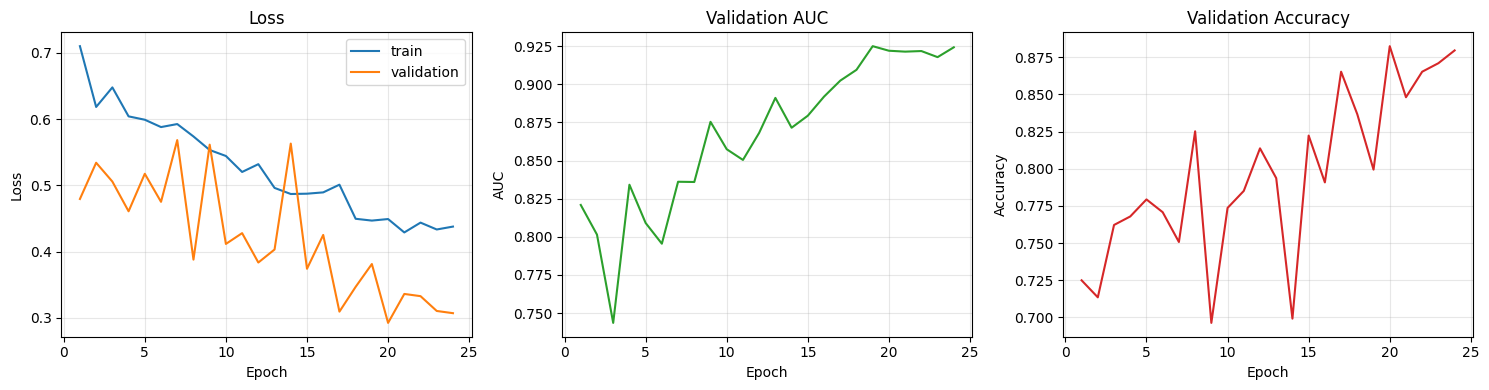

In [12]:
history_path = RESULTS_DIR_PATH / model_name / "training_history.json"
curves_save_path = RESULTS_DIR_PATH / model_name / "training_curves.png"
plot_training_curves(history_path, save_path=curves_save_path)

## 7. Test-set evaluation

Load the best checkpoint and evaluate on the held-out test split. This is the number we'll report in the report.

In [13]:
load_checkpoint(model, best_checkpoint_path, DEVICE)
test_loss, test_metrics, test_predictions = evaluate(model, test_loader, loss_function, DEVICE)

print("\n=== Test set results ===")
print(f"Loss:      {test_loss:.4f}")
print(f"AUC:       {test_metrics['auc']:.4f}")
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1:        {test_metrics['f1']:.4f}")
print(f"Confusion matrix [[TN, FP], [FN, TP]]: {test_metrics['confusion_matrix']}")

# Save for comparison across all models
test_metrics_save_path = RESULTS_DIR_PATH / model_name / "final_test_metrics.json"
with open(test_metrics_save_path, "w") as f:
    json.dump({"test_loss": test_loss, "test_metrics": test_metrics}, f, indent=2)

# Also save per-sample predictions for the per-class breakdown
predictions_save_path = RESULTS_DIR_PATH / model_name / "test_predictions.json"
with open(predictions_save_path, "w") as f:
    json.dump(test_predictions, f, indent=2)



=== Test set results ===
Loss:      0.3144
AUC:       0.9458
Accuracy:  0.8462
Precision: 0.9710
Recall:    0.8327
F1:        0.8966
Confusion matrix [[TN, FP], [FN, TP]]: [[63, 7], [47, 234]]


## 8. Per-manipulation breakdown

Split test-set predictions by manipulation method. This will tells us which fake types the hybrid handles best, and lets us compare against the per-class numbers from the baselines.

In [14]:
# Group predictions by class name
predictions_by_class = defaultdict(list)
labels_by_class = defaultdict(list)
for probability, true_label, class_name in zip(
    test_predictions["predicted_probs"],
    test_predictions["true_labels"],
    test_predictions["class_names"],
):
    predictions_by_class[class_name].append(probability)
    labels_by_class[class_name].append(true_label)

print("\n=== Per-class accuracy on test set (threshold = 0.5) ===")
print(f"{'Class':<20} {'N':>4}  {'Accuracy':>10}  {'Mean prob':>10}")
print("-" * 50)
for cls_name in sorted(predictions_by_class.keys()):
    probs = np.array(predictions_by_class[cls_name])
    true_labels = np.array(labels_by_class[cls_name])
    predicted = (probs >= 0.5).astype(int)
    accuracy = (predicted == true_labels).mean()
    print(f"{cls_name:<20} {len(probs):>4}  {accuracy:>10.4f}  {probs.mean():>10.4f}")


=== Per-class accuracy on test set (threshold = 0.5) ===
Class                   N    Accuracy   Mean prob
--------------------------------------------------
Deepfakes              71      0.8873      0.8258
Face2Face              70      0.8571      0.8150
FaceSwap               70      0.8143      0.7650
NeuralTextures         70      0.7714      0.7505
original               70      0.9000      0.2247


In [15]:
end_time = time.perf_counter()
time_elapsed = end_time - start_time
hours_elapsed = int(time_elapsed // 3600)
minutes_elapsed = int((time_elapsed % 3600) // 60)

print(f"Total execution time for {model_name}: {hours_elapsed:,}h {minutes_elapsed}m")

Total execution time for hybrid_cnn_transformer: 0h 40m
